In [139]:
#!/usr/bin/env python

"""vince_eda.ipynb:Initial Exploratory Analysis for the bee project.
"""
__author__      = "Vincent Amedekah "
__copyright__   = "Copyright 2022, Bee Project"

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from numpy import datetime64
import get_data as data
dataset_a, dataset_b,dataset_a_test,dataset_b_test,weather_data, bee_data, bee_full_data, air_data = data.get_data()
col_names=['year','state','colonies_inventory','unhealthy_days','very_unhealthy_days','hazardous_days','days_co','days_no2','days_ozone','days_pm2.5','days_pm10','temperature_max','temperature_min','precipitation_total']


## Aggregated USA states bee colony numbers

Text(0.5, 1.0, 'USA Annual Bee Colony Numbers')

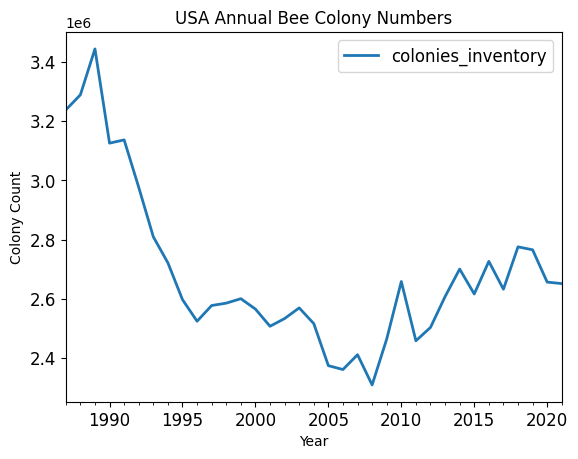

In [140]:
usa_colonies_aggregate =dataset_a[['year','colonies_inventory']].groupby('year').sum('colonies_inventory')
graph = usa_colonies_aggregate.plot(linewidth=2,fontsize=12)
graph.set_xlabel('Year')
graph.set_ylabel('Colony Count')
graph.legend(fontsize=12)
graph.set_title('USA Annual Bee Colony Numbers',fontsize=12)

## State bee colony numbers

Text(0.5, 1.0, 'Bee colony numbers by state')

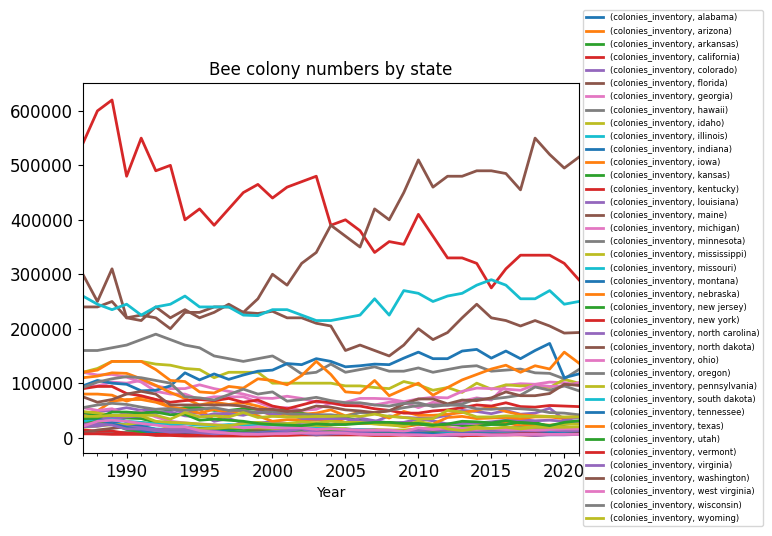

In [141]:
states_colonies_pvt = dataset_a.pivot(index=['year'],columns='state',values=['colonies_inventory'])
ax = states_colonies_pvt.plot(linewidth=2, fontsize=12)
ax.set_xlabel('Year')
ax.legend(loc='center left',bbox_to_anchor = (1,0.5), fontsize=6)
ax.set_title('Bee colony numbers by state')

## Top 5 states with higest bee colony numbers in our dataset

In [142]:
top5 = dataset_a[['state','colonies_inventory']].groupby('state').sum('colonies_inventory')['colonies_inventory'].nlargest(n=5).reset_index()
top5.head()

,state,colonies_inventory
0,california,14360000
1,north dakota,12720000
2,south dakota,8609000
3,florida,7373000
4,minnesota,4873000


Text(0.5, 1.0, 'Top 5 States bee colony numbers')

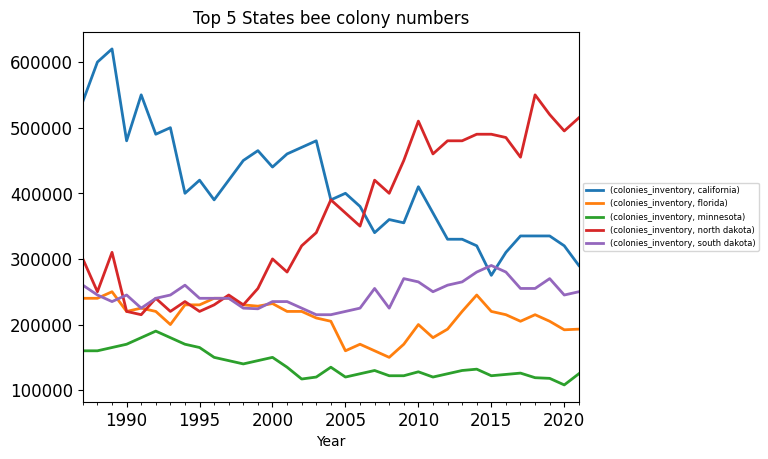

In [143]:
df_top5 = dataset_a[dataset_a['state'].isin(top5['state'])]
top5_pvt = df_top5.pivot(index=['year'],columns='state',values=['colonies_inventory'])
ax = top5_pvt.plot(linewidth=2, fontsize=12)
ax.set_xlabel('Year')
ax.legend(loc='center left',bbox_to_anchor = (1,0.5), fontsize=6)
ax.set_title('Top 5 States bee colony numbers')

### North Dakota has seen increase in bee colonies for a long time. why?

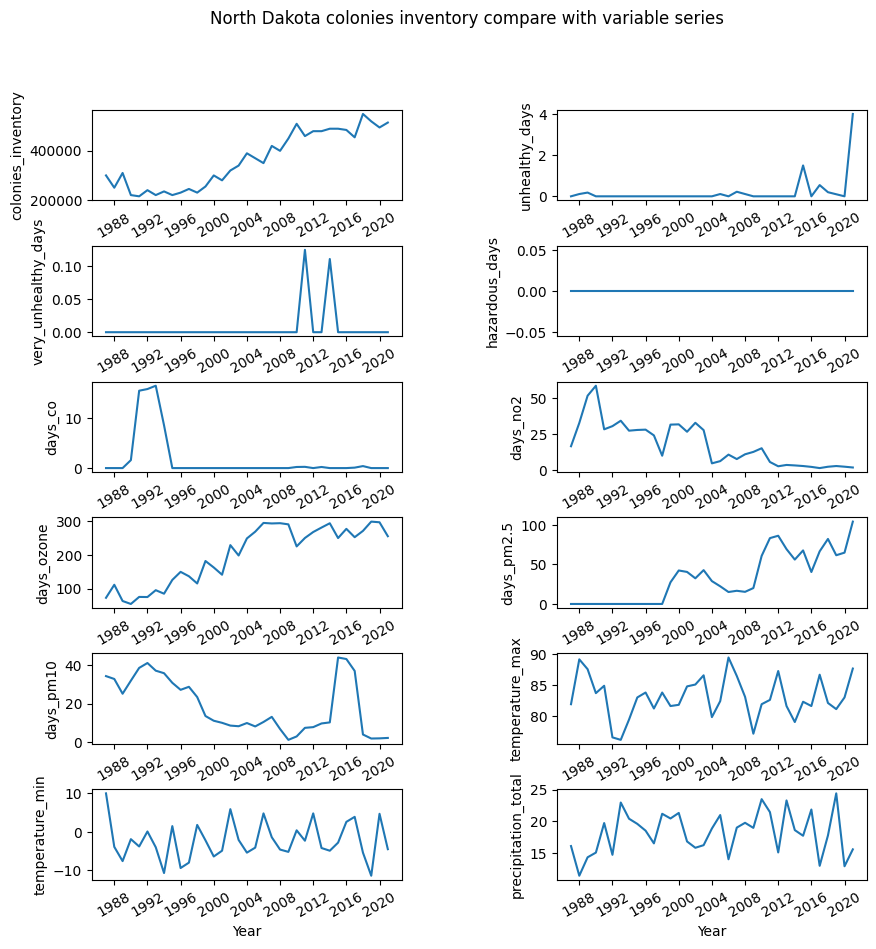

In [144]:
df = dataset_a[dataset_a['state']=='north dakota'][col_names]
fig,axs = plt.subplots(nrows=6,ncols=2)
fig.set_size_inches(10,10)
fig.subplots_adjust(wspace=0.5)
fig.subplots_adjust(hspace=0.5)
for c,ax in zip(df.columns[2:],axs.flatten()):
    ax.plot(df['year'],df[c])  
    ax.set(xlabel='Year',ylabel=c)  
    ax.tick_params(axis='x',labelrotation=30)
fig.suptitle('North Dakota colonies inventory compare with variable series')
plt.show()

North Dakota shows no harzadous day, minimal unhealthy days,days_co all remain less after 1996. days_ozone and days_pm2.5 shows increase over time. PM2.5 are more dangerous to animal health than Pm10 which shows decreasing over the year and rose around 2012 before falling around 2018 in North Dakota.

### California has seen decrease in bee colonies for a long time. why?

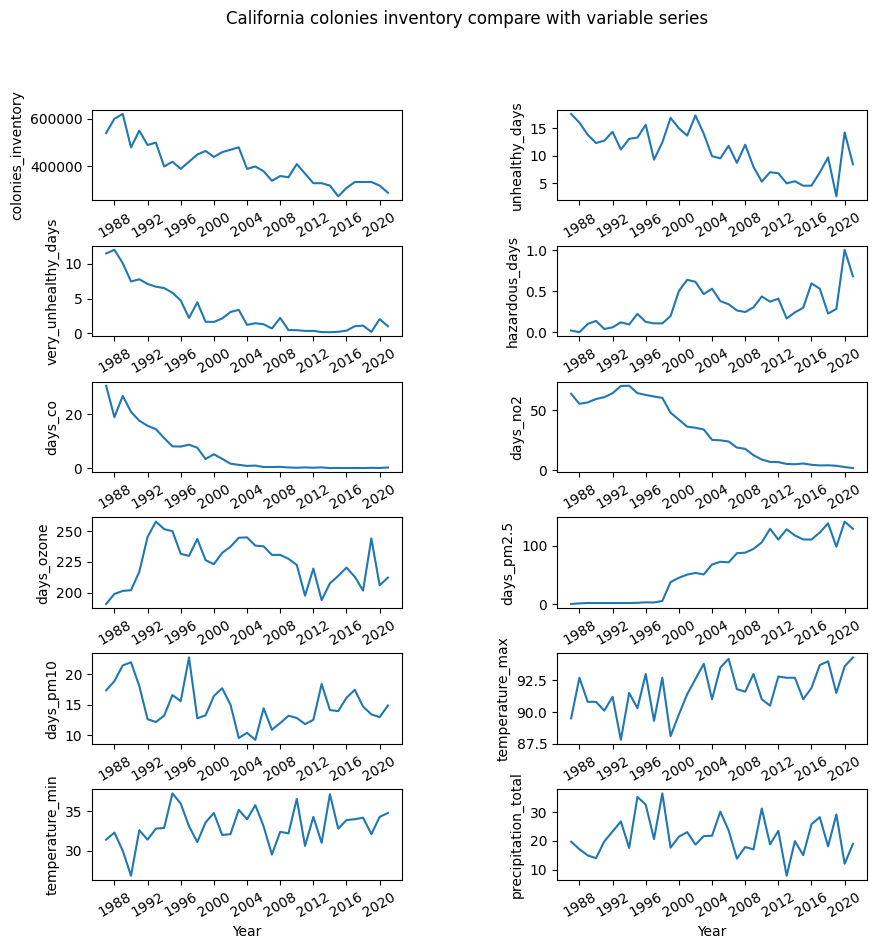

In [145]:
df = dataset_a[dataset_a['state']=='california'][col_names]
fig,axs = plt.subplots(nrows=6,ncols=2)
fig.set_size_inches(10,10)
fig.subplots_adjust(wspace=0.5)
fig.subplots_adjust(hspace=0.5)
for c,ax in zip(df.columns[2:],axs.flatten()):
    ax.plot(df['year'],df[c])  
    ax.set(xlabel='Year',ylabel=c)  
    ax.tick_params(axis='x',labelrotation=30)
fig.suptitle('California colonies inventory compare with variable series')
plt.show()

Hazardous days, pm2.5,days_Zone has been on the rise. PM10 still showed high. Days_co and days_No2 showed decrease over the years.


## Bottom 5 states with lowest bee colony numbers in our dataset

In [146]:
bottom5 = dataset_a[['state','colonies_inventory']].groupby('state').sum('colonies_inventory')['colonies_inventory'].nsmallest(n=5).reset_index()
bottom5.head()

,state,colonies_inventory
0,kentucky,186000
1,vermont,200000
2,virginia,309000
3,tennessee,338000
4,maine,360000


Text(0.5, 1.0, 'Bottom 5 States bee colony numbers')

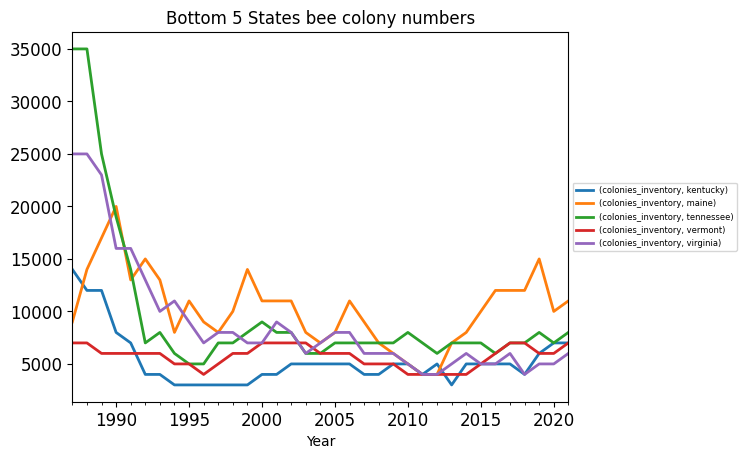

In [147]:
df_bottom5 = dataset_a[dataset_a['state'].isin(bottom5['state'])]
bottom5_pvt = df_bottom5.pivot(index=['year'],columns='state',values=['colonies_inventory'])
ax = bottom5_pvt.plot(linewidth=2, fontsize=12)
ax.set_xlabel('Year')
ax.legend(loc='center left',bbox_to_anchor = (1,0.5), fontsize=6)
ax.set_title('Bottom 5 States bee colony numbers')

### Kentucky has lowest bee colonies. why?

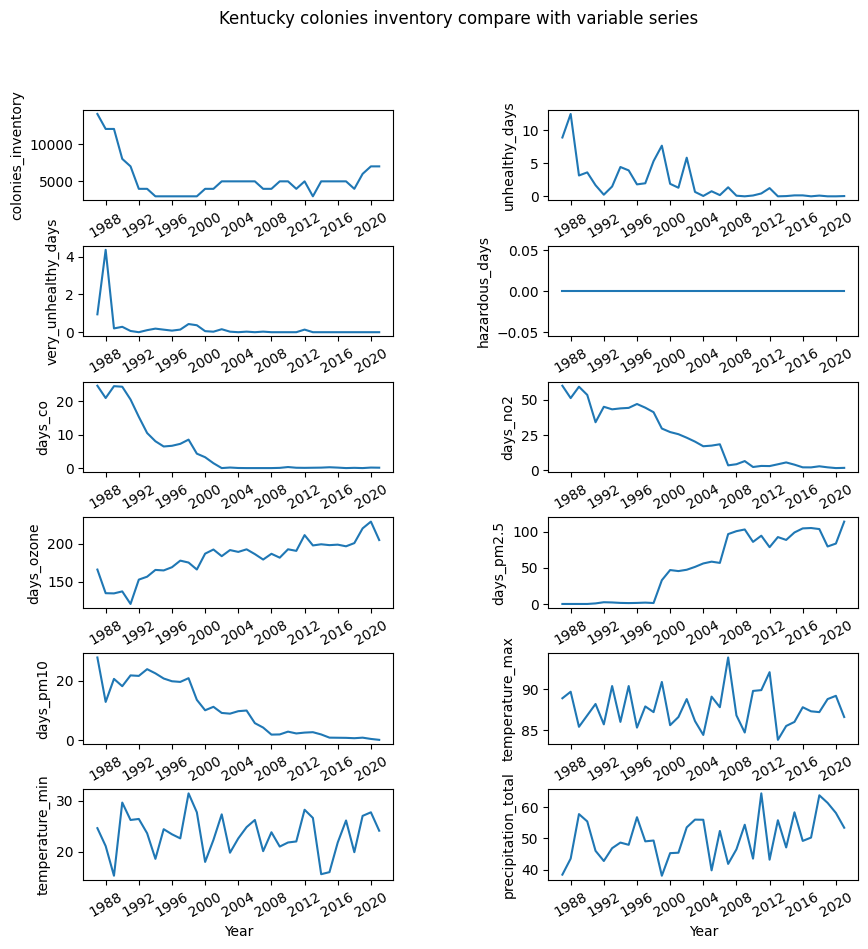

In [148]:
df = dataset_a[dataset_a['state']=='kentucky'][col_names]
fig,axs = plt.subplots(nrows=6,ncols=2)
fig.set_size_inches(10,10)
fig.subplots_adjust(wspace=0.5)
fig.subplots_adjust(hspace=0.5)
for c,ax in zip(df.columns[2:],axs.flatten()):
    ax.plot(df['year'],df[c])  
    ax.set(xlabel='Year',ylabel=c)  
    ax.tick_params(axis='x',labelrotation=30)
fig.suptitle('Kentucky colonies inventory compare with variable series')
plt.show()

Days_ozone and PM2.5 are seen on the rise in kentucky. Not that much different from other states, Could be the bee industry is just not big part of the state.

## Aggregate USA series to compare colonies_inventory with variable series

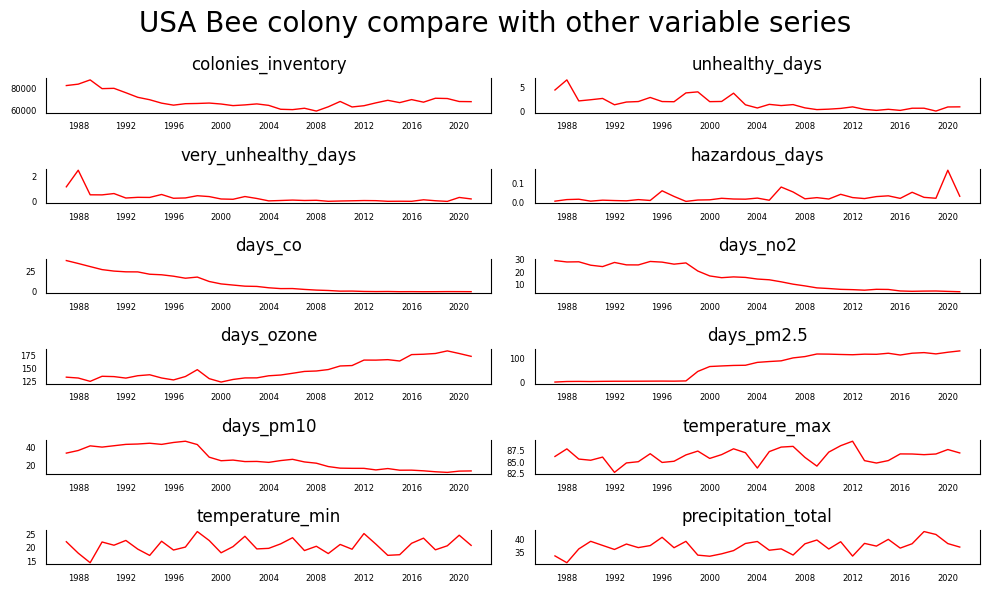

In [149]:
usa=dataset_a[[*col_names]]
usa=usa.groupby('year')[col_names[1:]].mean()

fig, axes = plt.subplots(nrows=6, ncols=2, figsize=(10,6))
for i, ax in enumerate(axes.flatten()):
    data = usa[usa.columns[i]]
    ax.plot(data, color='red', linewidth=1)    
    ax.set_title(usa.columns[i])
    ax.xaxis.set_ticks_position('none')
    ax.yaxis.set_ticks_position('none')
    ax.spines["top"].set_alpha(0)
    ax.tick_params(labelsize=6)
plt.suptitle('USA Bee colony compare with other variable series', fontsize=20)
plt.tight_layout();

### Normalized view of the USA series

c:\Users\vamedekah\Desktop\cda\venv\lib\site-packages\pandas\core\internals\blocks.py:402: RuntimeWarning: divide by zero encountered in log
  result = func(self.values, **kwargs)


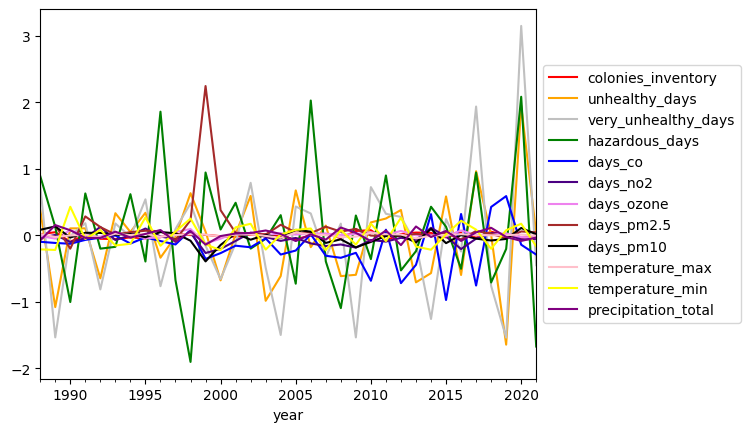

In [150]:
usa_normalized = np.log(usa).diff().dropna()
usa_normalized.plot(color=['red','orange','silver','green','blue','indigo','violet','brown','black','pink','yellow','purple']).legend(loc='center left',bbox_to_anchor=(1.0, 0.5))


From EDA, the most important series affecting colony numbers  are days_pm2.5,hazardous_days, days_ozone but we will make a better decission after feature tests

### Granger's casuality Test
The basis behind AutoRegression is that each of the time series in the system influences each other. 
With Granger's test we can test to see which of the series has p value greater than level of 0.05 which means they do not influence the system so we can drop that series.

In [151]:
from statsmodels.tsa.stattools import grangercausalitytests
maxlag=10
test = 'ssr_chi2test'
def grangers_causation_matrix(data, variables, test='ssr_chi2test', verbose=False):    
    """Check Granger Causality of all possible combinations of the Time series.
    The rows are the response variable, columns are predictors. The values in the table 
    are the P-Values. P-Values lesser than the significance level (0.05), implies 
    the Null Hypothesis that the coefficients of the corresponding past values is 
    zero, that is, the X does not cause Y can be rejected.

    data      : pandas dataframe containing the time series variables
    variables : list containing names of the time series variables.
    """
    df = pd.DataFrame(np.zeros((len(variables), len(variables))), columns=variables, index=variables)
    for c in df.columns:
        for r in df.index:
            test_result = grangercausalitytests(data[[r, c]], maxlag=maxlag, verbose=False)
            p_values = [round(test_result[i+1][0][test][1],4) for i in range(maxlag)]
            if verbose: print(f'Y = {r}, X = {c}, P Values = {p_values}')
            min_p_value = np.min(p_values)
            df.loc[r, c] = min_p_value
    df.columns = [var + '_x' for var in variables]
    df.index = [var + '_y' for var in variables]
    return df
granger = grangers_causation_matrix(usa,variables=usa.columns)
granger

,colonies_inventory_x,unhealthy_days_x,very_unhealthy_days_x,hazardous_days_x,days_co_x,days_no2_x,days_ozone_x,days_pm2.5_x,days_pm10_x,temperature_max_x,temperature_min_x,precipitation_total_x
colonies_inventory_y,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0,0.0000,0.0000,0.0005,0.0000,0.0000
unhealthy_days_y,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0,0.0000,0.0000,0.0000,0.0000,0.0000
very_unhealthy_days_y,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0,0.0000,0.0000,0.0000,0.0100,0.0000
hazardous_days_y,0.0001,0.0251,0.0006,1.0000,0.0100,0.0052,0.0,0.0029,0.0002,0.0000,0.0011,0.0000
days_co_y,0.0001,0.0000,0.0000,0.0744,1.0000,0.0000,0.0,0.0000,0.0000,0.0000,0.0000,0.0000
days_no2_y,0.0004,0.0000,0.0000,0.0174,0.0000,1.0000,0.0,0.0000,0.0000,0.0000,0.0001,0.0008
days_ozone_y,0.0000,0.0000,0.0000,0.0357,0.0000,0.0000,1.0,0.0000,0.0000,0.0000,0.0000,0.0000
days_pm2.5_y,0.0000,0.0000,0.0000,0.0001,0.0000,0.0000,0.0,1.0000,0.0000,0.0000,0.0000,0.0000
days_pm10_y,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0,0.0000,1.0000,0.0000,0.0000,0.0000
temperature_max_y,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0,0.0000,0.0002,1.0000,0.0000,0.1701


from above days_pm2.5 has p value(0.1576) greater than 0.05 for granger cause of temperature_min.  
precipitation has p value(0.1701) greater than 0.05 for granger cause of temperature_max.   
hazardous_days has p value(0.0744) greater than 0.05 for granger cause of days_co.  
We can remove temperature_min, temperature_max, precipitation and days_co from the dataset and retest.  
We keep days_pm2.5 and hazardous_days because they showed high correlation with the colonies inventory in EDA.  

In [152]:
usa_adjusted = usa.drop(['temperature_min','temperature_max','days_co','precipitation_total'],axis = 1)
grangers_causation_matrix(usa_adjusted,variables=usa_adjusted.columns)

,colonies_inventory_x,unhealthy_days_x,very_unhealthy_days_x,hazardous_days_x,days_no2_x,days_ozone_x,days_pm2.5_x,days_pm10_x
colonies_inventory_y,1.0000,0.0000,0.0000,0.0000,0.0000,0.0,0.0000,0.0000
unhealthy_days_y,0.0000,1.0000,0.0000,0.0000,0.0000,0.0,0.0000,0.0000
very_unhealthy_days_y,0.0000,0.0000,1.0000,0.0000,0.0000,0.0,0.0000,0.0000
hazardous_days_y,0.0001,0.0251,0.0006,1.0000,0.0052,0.0,0.0029,0.0002
days_no2_y,0.0004,0.0000,0.0000,0.0174,1.0000,0.0,0.0000,0.0000
days_ozone_y,0.0000,0.0000,0.0000,0.0357,0.0000,1.0,0.0000,0.0000
days_pm2.5_y,0.0000,0.0000,0.0000,0.0001,0.0000,0.0,1.0000,0.0000
days_pm10_y,0.0000,0.0000,0.0000,0.0000,0.0000,0.0,0.0000,1.0000


The granger causuality test is now passed for all series

### Cointegration Test
Cointegration helps to establish presence of statistically significant connection between two or more time series.

In [153]:
from statsmodels.tsa.vector_ar.vecm import coint_johansen

def cointegration_test(df, alpha=0.05): 
    """Perform Johanson's Cointegration Test and Report Summary"""
    out = coint_johansen(df,-1,5)
    d = {'0.90':0, '0.95':1, '0.99':2}
    traces = out.lr1
    cvts = out.cvt[:, d[str(1-alpha)]]
    def adjust(val, length= 6): return str(val).ljust(length)

    # Summary
    print('Name   ::  Test Stat > C(95%)    =>   Signif  \n', '--'*20)
    for col, trace, cvt in zip(df.columns, traces, cvts):
        print(adjust(col), ':: ', adjust(round(trace,2), 9), ">", adjust(cvt, 8), ' =>  ' , trace > cvt)
cointegration_test(usa_adjusted)

Name   ::  Test Stat > C(95%)    =>   Signif  
 ----------------------------------------
colonies_inventory ::  1245.13   > 143.6691  =>   True
unhealthy_days ::  898.63    > 111.7797  =>   True
very_unhealthy_days ::  634.63    > 83.9383   =>   True
hazardous_days ::  408.58    > 60.0627   =>   True
days_no2 ::  206.57    > 40.1749   =>   True
days_ozone ::  95.59     > 24.2761   =>   True
days_pm2.5 ::  12.78     > 12.3212   =>   True
days_pm10 ::  0.44      > 4.1296    =>   False


We see all the series in the USA_adjusted dataframe show significant relations over time except days_pm10.  
we will drop the days_pm10.
we will split the data into train,validation and test.  
We will use data from 1987 - 2016 for training and data from 2017 to 2021 for validation.    
2022 data will be used as test for the selected model.

In [154]:
usa_adjusted = usa_adjusted.drop('days_pm10',axis=1)
usa_adjusted.head()

,colonies_inventory,unhealthy_days,very_unhealthy_days,hazardous_days,days_no2,days_ozone,days_pm2.5
year,,,,,,,
1987-01-01,83025.641026,4.421316,1.168836,0.005783,29.455796,133.052913,0.000000
1988-01-01,84333.333333,6.479101,2.484957,0.014083,28.334489,131.428721,2.385228
1989-01-01,88307.692308,2.199878,0.535484,0.015965,28.470016,125.051243,2.770008
1990-01-01,80153.846154,2.440218,0.530008,0.005854,25.754409,134.742669,2.265188
1991-01-01,80435.897436,2.706561,0.635210,0.010979,24.645630,134.127225,3.007257


In [155]:
usa_train = usa_adjusted['1987-01-01':'2016-01-01']
usa_validation = usa_adjusted['2017-01-01':'2021-01-01']

print('Training :',usa_train.shape)
print('validation:',usa_validation.shape)

Training : (30, 7)
validation: (5, 7)


### Stationarity Test
VAR Model requires times series to be stationary, where mean and variance do not change over time.  
We will use the Augmented Dickey Full Test (ADF) to perform the stationarity test.

In [156]:
from statsmodels.tsa.stattools import adfuller

def adfuller_test(series, signif=0.05, name='', verbose=False):
    """Perform ADFuller to test for Stationarity of given series and print report"""
    r = adfuller(series, autolag='AIC')
    output = {'test_statistic':round(r[0], 4), 'pvalue':round(r[1], 4), 'n_lags':round(r[2], 4), 'n_obs':r[3]}
    p_value = output['pvalue'] 
    def adjust(val, length= 6): return str(val).ljust(length)

    # Print Summary
    print(f'    Augmented Dickey-Fuller Test on "{name}"', "\n   ", '-'*47)
    print(f' Null Hypothesis: Data has unit root. Non-Stationary.')
    print(f' Significance Level    = {signif}')
    print(f' Test Statistic        = {output["test_statistic"]}')
    print(f' No. Lags Chosen       = {output["n_lags"]}')

    for key,val in r[4].items():
        print(f' Critical value {adjust(key)} = {round(val, 3)}')

    if p_value <= signif:
        print(f" => P-Value = {p_value}. Rejecting Null Hypothesis.")
        print(f" => Series is Stationary.")
    else:
        print(f" => P-Value = {p_value}. Weak evidence to reject the Null Hypothesis.")
        print(f" => Series is Non-Stationary.")   

# ADF Test on each column
for name, column in usa_train.iteritems():
    adfuller_test(column, name=column.name)
    print('\n') 

    Augmented Dickey-Fuller Test on "colonies_inventory" 
    -----------------------------------------------
 Null Hypothesis: Data has unit root. Non-Stationary.
 Significance Level    = 0.05
 Test Statistic        = -1.9968
 No. Lags Chosen       = 0
 Critical value 1%     = -3.679
 Critical value 5%     = -2.968
 Critical value 10%    = -2.623
 => P-Value = 0.288. Weak evidence to reject the Null Hypothesis.
 => Series is Non-Stationary.


    Augmented Dickey-Fuller Test on "unhealthy_days" 
    -----------------------------------------------
 Null Hypothesis: Data has unit root. Non-Stationary.
 Significance Level    = 0.05
 Test Statistic        = -1.2428
 No. Lags Chosen       = 2
 Critical value 1%     = -3.7
 Critical value 5%     = -2.976
 Critical value 10%    = -2.628
 => P-Value = 0.6549. Weak evidence to reject the Null Hypothesis.
 => Series is Non-Stationary.


    Augmented Dickey-Fuller Test on "very_unhealthy_days" 
    ----------------------------------------------

The Dickey fuller test shows most of the series are not sationary so we will try to make them stationary by differencing.

In [157]:
# 1st difference
usa_differenced = usa_train.diff().dropna()
for name, column in usa_differenced.iteritems():
    adfuller_test(column, name=column.name)
    print('\n')

    Augmented Dickey-Fuller Test on "colonies_inventory" 
    -----------------------------------------------
 Null Hypothesis: Data has unit root. Non-Stationary.
 Significance Level    = 0.05
 Test Statistic        = -4.0274
 No. Lags Chosen       = 1
 Critical value 1%     = -3.7
 Critical value 5%     = -2.976
 Critical value 10%    = -2.628
 => P-Value = 0.0013. Rejecting Null Hypothesis.
 => Series is Stationary.


    Augmented Dickey-Fuller Test on "unhealthy_days" 
    -----------------------------------------------
 Null Hypothesis: Data has unit root. Non-Stationary.
 Significance Level    = 0.05
 Test Statistic        = -7.901
 No. Lags Chosen       = 1
 Critical value 1%     = -3.7
 Critical value 5%     = -2.976
 Critical value 10%    = -2.628
 => P-Value = 0.0. Rejecting Null Hypothesis.
 => Series is Stationary.


    Augmented Dickey-Fuller Test on "very_unhealthy_days" 
    -----------------------------------------------
 Null Hypothesis: Data has unit root. Non-Stati

All the series are stationary after the first differencing so we can now continue to model building using usa_differenced dataframe.


### build model

In [158]:
from statsmodels.tsa.api import VAR
from statsmodels.tools.eval_measures import rmse, aic
model = VAR(usa_differenced)
order = model.select_order()
order.summary()

c:\Users\vamedekah\Desktop\cda\venv\lib\site-packages\statsmodels\tsa\base\tsa_model.py:471: ValueWarning: No frequency information was provided, so inferred frequency AS-JAN will be used.
  self._init_dates(dates, freq)


,AIC,BIC,FPE,HQIC
0,10.51,10.85*,3.681e+04,10.61
1,11.12,13.81,7.712e+04,11.92
2,7.419*,12.46,4494.*,8.917*


We will use lag = 2 to build the model as it achieves the minimum for the measures AIC and FPE

In [159]:
model_fitted = model.fit(2)
model_fitted.summary()

  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Sun, 04, Dec, 2022
Time:                     16:48:23
--------------------------------------------------------------------
No. of Equations:         7.00000    BIC:                    12.4583
Nobs:                     27.0000    HQIC:                   8.91740
Log likelihood:          -263.335    FPE:                    4493.98
AIC:                      7.41893    Det(Omega_mle):         203.907
--------------------------------------------------------------------
Results for equation colonies_inventory
                            coefficient       std. error           t-stat            prob
-----------------------------------------------------------------------------------------
const                        545.737059      1584.324367            0.344           0.731
L1.colonies_inventory         -0.053503         0.313974           -0.170           0.865
L1.unhealth

Forecast for next 5 years 2017-2021 - Valdidation data

In [160]:
lag_order = model_fitted.k_ar
forecast_input = usa_differenced.values[-lag_order:]
forecasted = model_fitted.forecast(y=forecast_input, steps=5)
df_forecasted = pd.DataFrame(forecasted,index =usa_validation.index[-5:],columns=usa_validation.columns)
df_forecasted

,colonies_inventory,unhealthy_days,very_unhealthy_days,hazardous_days,days_no2,days_ozone,days_pm2.5
year,,,,,,,
2017-01-01,2236.373750,0.604438,0.046684,-0.016970,-0.582329,3.514717,9.336875
2018-01-01,112.829407,-0.304379,-0.062686,-0.016255,-1.606395,-4.597158,14.018295
2019-01-01,25.033405,-0.902775,-0.117223,0.025485,-3.006617,-1.130779,10.682403
2020-01-01,853.711061,0.433037,0.029443,-0.015256,-0.712018,5.261978,3.860312
2021-01-01,-1244.014682,0.245909,0.052709,-0.000820,-0.270354,2.011859,1.915383


invert transformation to original scale of data

In [161]:
def de_difference(df_forecast,df_original):
       df_revert = df_forecast.copy()
       columns = df_forecast.columns
       for col in columns:   
       # Roll back 1st Diff
              df_revert[str(col)] = df_original[col].iloc[-1] + df_revert[str(col)].cumsum()
       return df_revert
df_forecasted_revert=de_difference(df_forecasted,usa_adjusted)
df_forecasted_revert

,colonies_inventory,unhealthy_days,very_unhealthy_days,hazardous_days,days_no2,days_ozone,days_pm2.5
year,,,,,,,
2017-01-01,70236.373750,1.598237,0.255048,0.014730,4.040174,176.417215,141.354774
2018-01-01,70349.203157,1.293857,0.192362,-0.001525,2.433779,171.820058,155.373070
2019-01-01,70374.236562,0.391083,0.075139,0.023960,-0.572838,170.689279,166.055472
2020-01-01,71227.947622,0.824120,0.104582,0.008704,-1.284856,175.951257,169.915785
2021-01-01,69983.932940,1.070029,0.157291,0.007884,-1.555210,177.963115,171.831168


In [162]:
usa_validation

,colonies_inventory,unhealthy_days,very_unhealthy_days,hazardous_days,days_no2,days_ozone,days_pm2.5
year,,,,,,,
2017-01-01,67512.820513,0.712801,0.140084,0.052581,4.960837,176.921920,122.200633
2018-01-01,71179.487179,0.716109,0.065437,0.025858,5.121134,178.338215,124.744811
2019-01-01,70923.076923,0.138388,0.014057,0.021064,5.199198,183.300888,119.292206
2020-01-01,68128.205128,0.970996,0.326733,0.168840,4.878721,178.298193,126.308719
2021-01-01,68000.000000,0.993798,0.208363,0.031700,4.622504,172.902498,132.017900


Model Performance Metrics

In [163]:
# average for all validation years
def performanceMetrics(df_actual,df_forecast):
    mae = np.mean(np.abs(usa_validation-df_forecasted_revert))
    mse = np.mean(np.square(usa_validation-df_forecasted_revert))
    rmse = np.sqrt(np.mean(np.square(usa_validation-df_forecasted_revert)))
    mape = np.mean(np.abs((df_actual-df_forecast)/df_actual))*100
    metrics = pd.concat([mae,mse,rmse,mape],axis=1)
    metrics.columns = ['mae','mse','rmse','mape']
    return metrics
metrics = performanceMetrics(usa_validation,df_forecasted_revert)
metrics

c:\Users\vamedekah\Desktop\cda\venv\lib\site-packages\numpy\core\fromnumeric.py:3430: FutureWarning: In a future version, DataFrame.mean(axis=None) will return a scalar mean over the entire DataFrame. To retain the old behavior, use 'frame.mean(axis=0)' or just 'frame.mean()'
  return mean(axis=axis, dtype=dtype, out=out, **kwargs)


,mae,mse,rmse,mape
colonies_inventory,1837.270611,4.390547e+06,2095.363118,2.688372
unhealthy_days,0.387797,2.418055e-01,0.491737,82.058816
very_unhealthy_days,0.115239,1.700336e-02,0.130397,160.608921
hazardous_days,0.050416,5.680324e-03,0.075368,72.321383
days_no2,4.344269,2.350794e+01,4.848499,88.406488
days_ozone,5.408405,4.658235e+01,6.825126,3.012730
days_pm2.5,35.993200,1.395689e+03,37.358926,28.821869


In [164]:
def performanceMetricsByYear(df_actual,df_forecast):
    metricsbyyear = pd.DataFrame()
    for year in df_actual.index:
        actual = df_actual.loc[[year]] 
        forecast = df_forecast.loc[[year]]
        mae = np.mean(np.abs(actual-forecast))
        mse = np.mean(np.square(actual-forecast))
        rmse = np.sqrt(np.mean(np.square(actual-forecast)))
        mape = np.mean(np.abs((actual-forecast)/actual))*100
        metrics = pd.concat([mae,mse,rmse,mape],axis=1)
        metrics.columns = ['mae','mse','rmse','mape']
        metrics['year']= year
        metricsbyyear = pd.concat([metricsbyyear,metrics],axis = 0)
    return metricsbyyear 
metricsbyyear = performanceMetricsByYear(usa_validation,df_forecasted_revert)
metricsbyyear

c:\Users\vamedekah\Desktop\cda\venv\lib\site-packages\numpy\core\fromnumeric.py:3430: FutureWarning: In a future version, DataFrame.mean(axis=None) will return a scalar mean over the entire DataFrame. To retain the old behavior, use 'frame.mean(axis=0)' or just 'frame.mean()'
  return mean(axis=axis, dtype=dtype, out=out, **kwargs)
c:\Users\vamedekah\Desktop\cda\venv\lib\site-packages\numpy\core\fromnumeric.py:3430: FutureWarning: In a future version, DataFrame.mean(axis=None) will return a scalar mean over the entire DataFrame. To retain the old behavior, use 'frame.mean(axis=0)' or just 'frame.mean()'
  return mean(axis=axis, dtype=dtype, out=out, **kwargs)
c:\Users\vamedekah\Desktop\cda\venv\lib\site-packages\numpy\core\fromnumeric.py:3430: FutureWarning: In a future version, DataFrame.mean(axis=None) will return a scalar mean over the entire DataFrame. To retain the old behavior, use 'frame.mean(axis=0)' or just 'frame.mean()'
  return mean(axis=axis, dtype=dtype, out=out, **kwargs

,mae,mse,rmse,mape,year
colonies_inventory,2723.553237,7.417742e+06,2723.553237,4.034127,2017-01-01
unhealthy_days,0.885435,7.839957e-01,0.885435,124.219102,2017-01-01
very_unhealthy_days,0.114963,1.321657e-02,0.114963,82.067275,2017-01-01
hazardous_days,0.037851,1.432703e-03,0.037851,71.986352,2017-01-01
days_no2,0.920662,8.476188e-01,0.920662,18.558607,2017-01-01
days_ozone,0.504705,2.547270e-01,0.504705,0.285270,2017-01-01
days_pm2.5,19.154141,3.668811e+02,19.154141,15.674339,2017-01-01
colonies_inventory,830.284022,6.893716e+05,830.284022,1.166465,2018-01-01
unhealthy_days,0.577748,3.337932e-01,0.577748,80.678839,2018-01-01
very_unhealthy_days,0.126925,1.610991e-02,0.126925,193.964699,2018-01-01


In [165]:
#output for only bee colony
metricsbyyear.loc[['colonies_inventory']]

,mae,mse,rmse,mape,year
colonies_inventory,2723.553237,7.417742e+06,2723.553237,4.034127,2017-01-01
colonies_inventory,830.284022,6.893716e+05,830.284022,1.166465,2018-01-01
colonies_inventory,548.840361,3.012257e+05,548.840361,0.773853,2019-01-01
colonies_inventory,3099.742494,9.608404e+06,3099.742494,4.549867,2020-01-01
colonies_inventory,1983.932940,3.935990e+06,1983.932940,2.917548,2021-01-01


<AxesSubplot:title={'center':'Bee colonies numbers forecased vs actual'}, xlabel='year'>

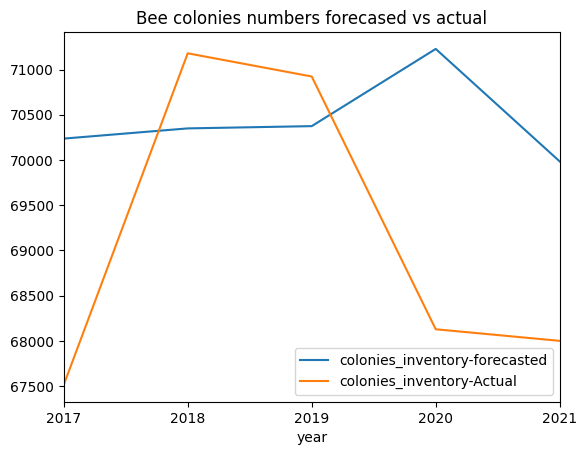

In [166]:
forecast=df_forecasted_revert[['colonies_inventory']]
#fig, axes = plt.subplots(nrows=1, ncols=1, figsize=(10,6))
#for i, ax in enumerate(axes.flatten()):
#forecast = df_forecasted_revert[df_forecasted_revert.columns[i]]
val = usa_validation[['colonies_inventory']]
data = pd.concat([forecast,val],axis=1)
data.columns = [data.columns[0]+'-forecasted',data.columns[1]+'-Actual']
data.plot(title='Bee colonies numbers forecased vs actual')
# data.columns = [data.columns[0]+'-forecasted',data.columns[1]+'-Actual']
# ax.plot(data)    
# ax.set_title('colonies_inventory Validation Vs Forecasted')
# ax.xaxis.set_ticks_position('none')
# ax.yaxis.set_ticks_position('none')
# ax.spines["top"].set_alpha(0)
# ax.tick_params(labelsize=6)
# plt.suptitle('Validation data vs Forecasted for USA Bee colony compare with other variable series', fontsize=20)
# plt.tight_layout();




In [167]:
data

,colonies_inventory-forecasted,colonies_inventory-Actual
year,,
2017-01-01,70236.373750,67512.820513
2018-01-01,70349.203157,71179.487179
2019-01-01,70374.236562,70923.076923
2020-01-01,71227.947622,68128.205128
2021-01-01,69983.932940,68000.000000


Forecasting for Test years - 2022. Need to retrain the model with all the data sets After selecting the best model between LSTM and VAR

In [168]:
final_train = usa_adjusted['1987-01-01':'2021-01-01']
usa_differenced = final_train.diff().dropna()
model = VAR(usa_differenced)
final_model = model.fit(2)
lag_order = final_model.k_ar
forecast_input = usa_differenced.values[-lag_order:]
future = final_model.forecast(y=forecast_input, steps=4)
df_future = pd.DataFrame(future,index =['2022-01-01','2023-01-01','2024-01-01','2025-01-01'],columns=final_train.columns)
df_future_revert=de_difference(df_future,final_train)
df_future_revert.index.name='year'
df_future_revert


c:\Users\vamedekah\Desktop\cda\venv\lib\site-packages\statsmodels\tsa\base\tsa_model.py:471: ValueWarning: No frequency information was provided, so inferred frequency AS-JAN will be used.
  self._init_dates(dates, freq)


,colonies_inventory,unhealthy_days,very_unhealthy_days,hazardous_days,days_no2,days_ozone,days_pm2.5
year,,,,,,,
2022-01-01,63348.063277,0.343108,0.199612,0.053329,6.995119,194.061362,109.897382
2023-01-01,67669.020678,2.268205,0.429598,0.159832,1.996252,180.133015,147.147462
2024-01-01,67619.161871,0.035281,0.068599,-0.005115,2.765645,176.775609,145.915950
2025-01-01,62412.190462,-0.305698,0.147673,0.117498,2.287549,196.139900,132.504842


Plot of future forecast

<AxesSubplot:title={'center':'Forecasted Bee Colony numbers from 2022'}, xlabel='year'>

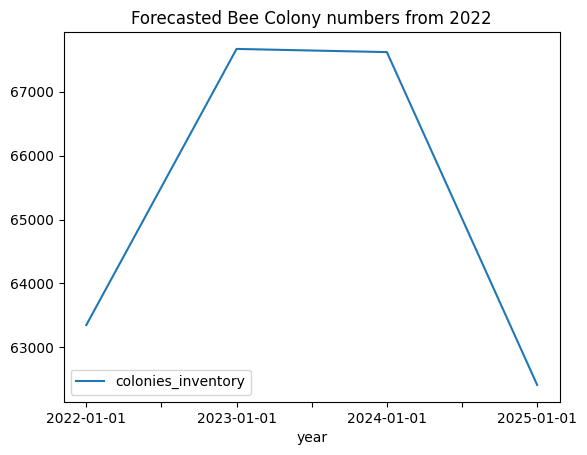

In [169]:
#fig = plt.figure(figsize=(10,6))
#for i, ax in enumerate(axes.flatten()):
data = df_future_revert[['colonies_inventory']]
data.plot(title='Forecasted Bee Colony numbers from 2022')
#     ax.plot(data, color='red', linewidth=1)    
#     ax.set_title(usa.columns[i])
#     ax.xaxis.set_ticks_position('none')
#     ax.yaxis.set_ticks_position('none')
#     ax.spines["top"].set_alpha(0)
#     ax.tick_params(labelsize=6)
# plt.suptitle('Future USA Bee colony compare with other variable series', fontsize=20)
# plt.tight_layout();

Test Data for 2022

In [170]:
usa_test =dataset_a_test[[*col_names]]
usa_test =usa_test.groupby('year')[col_names[1:]].mean()
usa_test = usa_test[['colonies_inventory']]
test_forecast = df_future_revert.loc[['2022-01-01']]
test_forecast = test_forecast[['colonies_inventory']]
test_forecast

,colonies_inventory
year,
2022-01-01,63348.063277


In [171]:
usa_test

,colonies_inventory
year,
2022-01-01,72673.076923



### Conclusion
RMSE is the metric used to determine our best model for dataset A.  
The VAR RMSE is 1837.2706 and the LSTM RMSE is 4955.18202 for all of the USA aggregated data.
This means the VAR model performs better at the USA aggregated level. We will therefore propose the VAR model for predicting the bee colony inventory for the USA using the variables unhealthy_days, very_unhealthy_days, hazardous_days, days_no2,days_ozone and days_pm2.5. 
From the explanatory data analyis, the most important series for predicting the colony inventory are the pm2.5 and hazardous_days. The PM2.5 are tiny particles in the air that reduce visibility and cause the air to appear hazy when levels are elevated. According to a study in India, the pm2.5 does have a huge impact on the honey bee population. The harzadous_days in our dataset are those days when the air quality is elevated beyond its normal threshold. 
So we can conclude pollution has a big impact on bee colonies in the United States. From the VAR model predictions, the bee colonies will rise to approximately 70,000 in 2023 but will decrease to approximately 62,000 in 2025 on average in the United States.
We therefore recommend business and government authorities in charge of making policies at state and federal level that will impact the bee colonies to keep these factors in check if they wish to improve the bee population with everything held constant.

With dataset b, the time series decomposition and testing showed its not appropriate for VAR and LSTM because it has very few data points for the series for the models to learn. However, we tried the mixed effect random forest on dataset b but we did not get a good predictions due to very high rmse so we discard the dataset b in our final modeling.

